# FYP Title: Vision-Based Vehicle Counting and People-Flow Estimation System

## 1. Project Background
* Malaysia's highway Rest & Recreation (R&R) network provides essential facilities (restrooms, food courts, fuel) and critical spaces to combat driver fatigue.
* With multiple major festive holidays throughout the year, such as Hari Raya, Chinese New Year, and Deepavali, highways and R&R stops frequently experience overwhelming crowds.
* Effective facility management heavily depends on an accurate understanding of usage patterns, requiring comprehensive monitoring of both vehicle traffic and people flow.
* Existing monitoring relies on manual surveillance or basic automated counting, lacking detailed classification and limiting data-driven capacity planning.
* The integration of computer vision and state-of-the-art deep learning (such as Transformer-based models like RF-DETR) enables 24/7 automated, highly accurate, and labour-saving traffic analysis.

---

## 2. Problem Statement
* **Lack of Granularity in Classification:** Existing systems broadly classify vehicles (e.g., "heavy" vs. "light") or rely on generic "car" class. This fails to distinguish between specific vehicle types like sedans, SUVs, and pickups, which possess significantly different passenger seating capacities, ultimately skewing any subsequent people-flow estimates.
* **Disconnect Between Vehicles and People:** Facility operations (restroom capacity, food court staffing) are driven by human footfall, yet current systems cannot translate vehicle counts into meaningful human occupancy estimates.
* **Absence of Real-Time Analytics:** Many surveillance setups act as passive recorders isolated in local processing units, lacking centralised, real-time visualisation and historical trend analysis for stakeholders.

---

## 3. Project Objective
* **Fine-Grained Classification:** To implement an vehicle detection and classification model (RF-DETR) that accurately distinguishes between seven specific categories: sedan, SUV, pickup, van, motorcycle, bus, and truck.
* **People-Flow Estimation:** To develop an automated algorithm integrating object tracking algorithm (ByteTrack) for vehicle tracking alongside heuristic models (based on minimum and maximum seat capacities) to estimate human footfall.
* **Accessible Analytics Infrastructure:** To deploy a comprehensive web-based dashboard using Flask and Firebase that analyse traffic camera footage/live stream, visualises real-time people flow and historical traffic data for immediate operational insights.

### Dataset Class Distribution

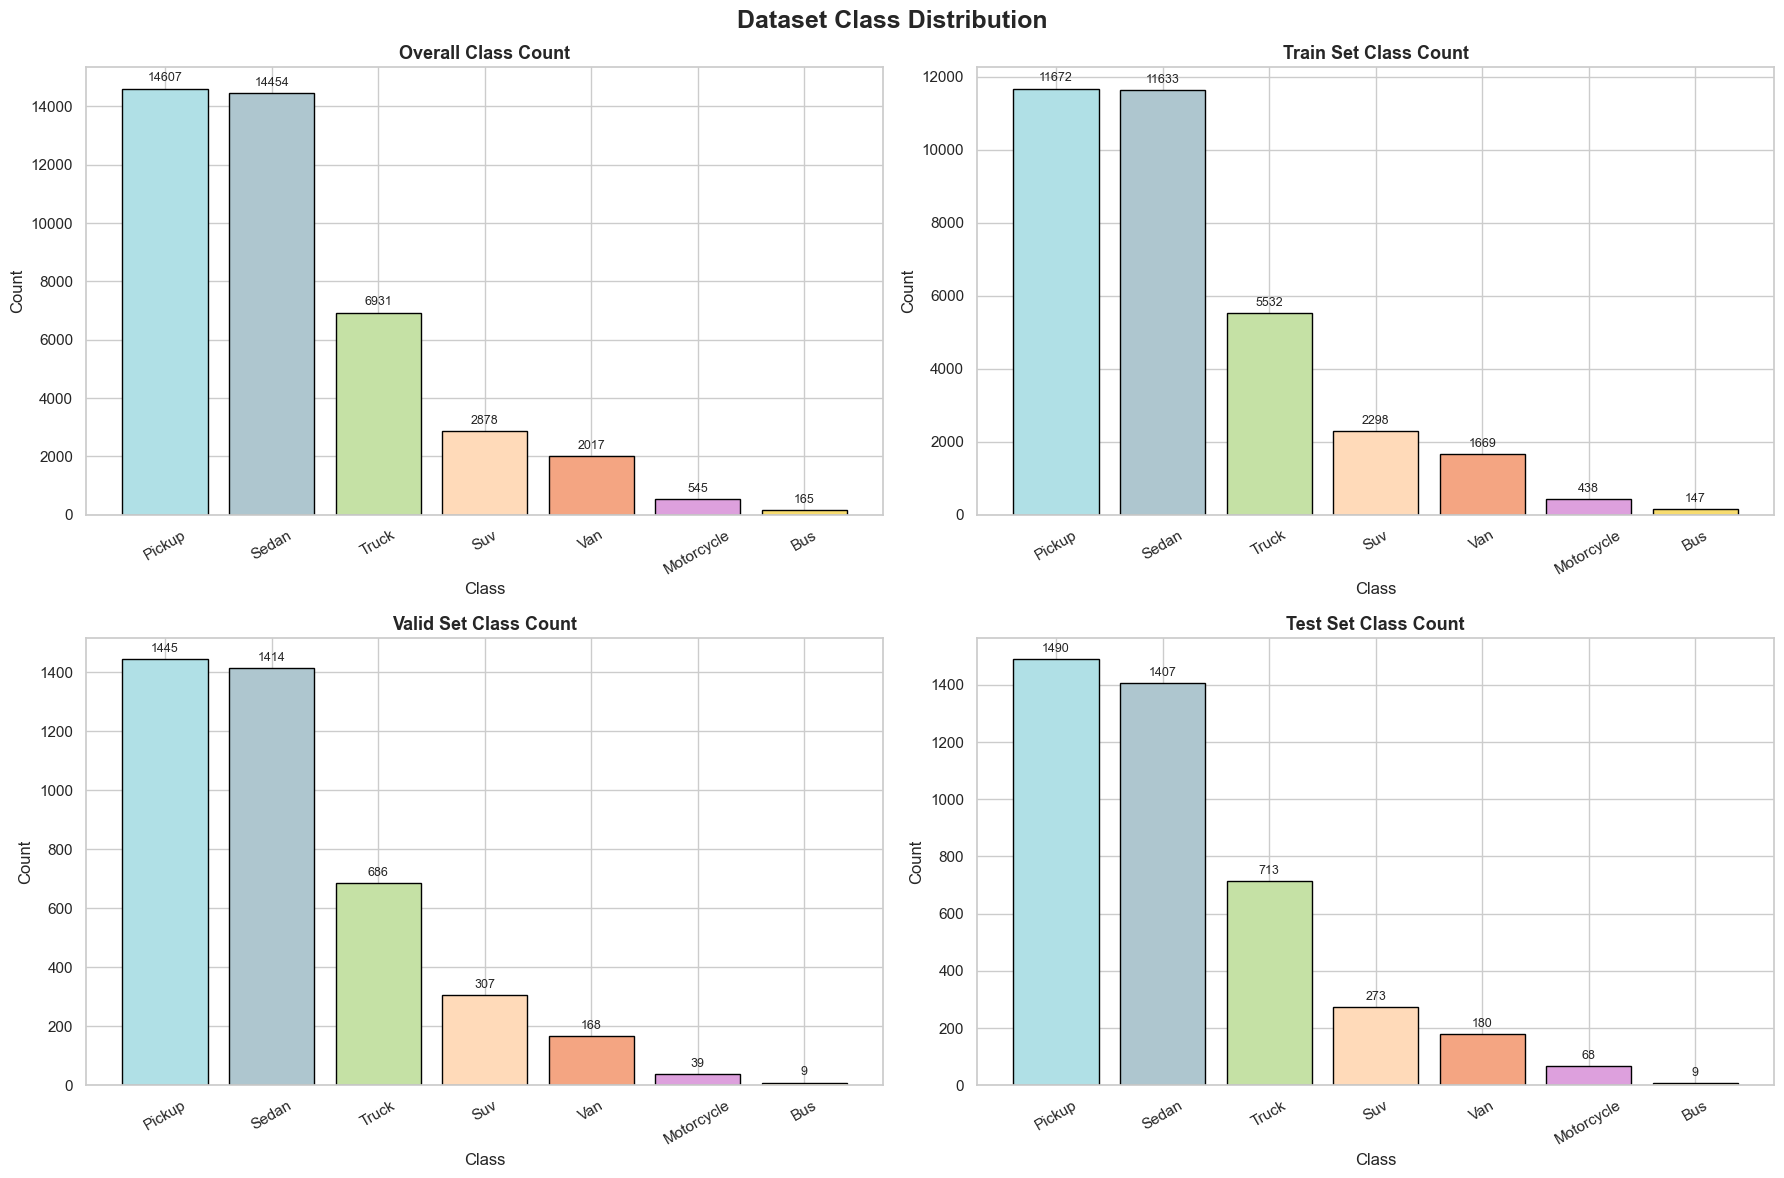

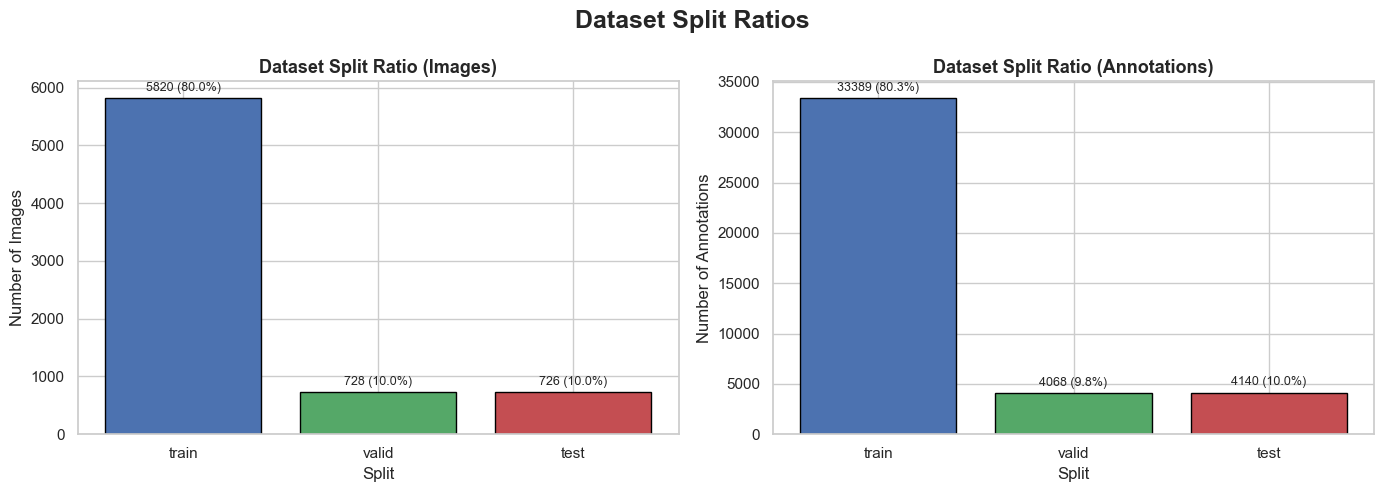

In [5]:
from pathlib import Path
import json
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset_dir = Path("imbalanced-2")
splits = ["train", "valid", "test"]

sns.set_theme(style="whitegrid")

def load_split_counts(dataset_dir, split):
    json_path = dataset_dir / split / "_annotations.coco.json"
    if not json_path.exists():
        raise FileNotFoundError(f"Missing annotation file: {json_path}")

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    cat_map = {c["id"]: c["name"] for c in data["categories"]}
    class_counts = Counter(cat_map[ann["category_id"]] for ann in data["annotations"])

    return class_counts, len(data["images"]), len(data["annotations"])

# Load all splits
split_class_counts = {}
split_image_counts = {}
split_annotation_counts = {}

for split in splits:
    counts, n_images, n_annotations = load_split_counts(dataset_dir, split)
    split_class_counts[split] = counts
    split_image_counts[split] = n_images
    split_annotation_counts[split] = n_annotations

# Collect classes
all_classes = sorted({
    cls
    for split_counts in split_class_counts.values()
    for cls in split_counts.keys()
})

df_split = pd.DataFrame(
    {
        split: [split_class_counts[split].get(cls, 0) for cls in all_classes]
        for split in splits
    },
    index=all_classes
)

overall_counts = df_split.sum(axis=1).sort_values(ascending=False)
train_counts = df_split["train"].sort_values(ascending=False)
valid_counts = df_split["valid"].sort_values(ascending=False)
test_counts = df_split["test"].sort_values(ascending=False)

# Fixed color per class
class_colors = {
    "Sedan": "#AEC6CF",      # soft blue
    "Suv": "#FFDAB9",        # peach
    "Pickup": "#B0E0E6",     # powder blue
    "Van": "#F4A582",        # light coral
    "Motorcycle": "#DDA0DD", # plum
    "Bus": "#F7DC6F",        # pastel yellow
    "Truck": "#C5E1A5",      # light green
}

def plot_bar(ax, series, title):
    colors = [class_colors.get(cls, "#7f7f7f") for cls in series.index]
    bars = ax.bar(series.index, series.values, color=colors, edgecolor="black")
    ax.set_title(title, fontsize=13, weight="bold")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)
    ax.bar_label(bars, padding=3, fontsize=9)

# =========================
# Figure 1: Class Distribution
# =========================
fig1, axes1 = plt.subplots(2, 2, figsize=(18, 12))
axes1 = axes1.flatten()

plot_bar(axes1[0], overall_counts, "Overall Class Count")
plot_bar(axes1[1], train_counts, "Train Set Class Count")
plot_bar(axes1[2], valid_counts, "Valid Set Class Count")
plot_bar(axes1[3], test_counts, "Test Set Class Count")

fig1.suptitle("Dataset Class Distribution", fontsize=18, weight="bold")
fig1.tight_layout()
plt.show()

# =========================
# Figure 2: Split Ratios
# =========================
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

image_series = pd.Series(split_image_counts)
annotation_series = pd.Series(split_annotation_counts)

split_colors = ["#4C72B0", "#55A868", "#C44E52"]

image_bars = axes2[0].bar(
    image_series.index,
    image_series.values,
    color=split_colors,
    edgecolor="black"
)
axes2[0].set_title("Dataset Split Ratio (Images)", fontsize=13, weight="bold")
axes2[0].set_xlabel("Split")
axes2[0].set_ylabel("Number of Images")
axes2[0].bar_label(
    image_bars,
    labels=[f"{v} ({v / image_series.sum():.1%})" for v in image_series.values],
    padding=3,
    fontsize=9
)

annotation_bars = axes2[1].bar(
    annotation_series.index,
    annotation_series.values,
    color=split_colors,
    edgecolor="black"
)
axes2[1].set_title("Dataset Split Ratio (Annotations)", fontsize=13, weight="bold")
axes2[1].set_xlabel("Split")
axes2[1].set_ylabel("Number of Annotations")
axes2[1].bar_label(
    annotation_bars,
    labels=[f"{v} ({v / annotation_series.sum():.1%})" for v in annotation_series.values],
    padding=3,
    fontsize=9
)

fig2.suptitle("Dataset Split Ratios", fontsize=18, weight="bold")
fig2.tight_layout()
plt.show()

### Sample Images in the Dataset

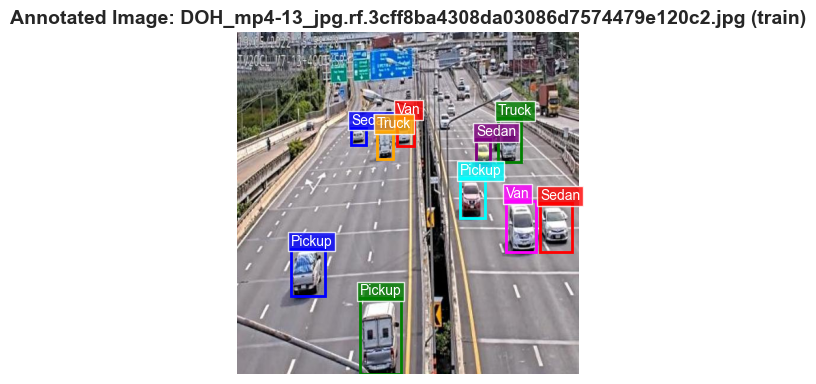

In [ ]:
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

dataset_dir = Path("imbalanced-2")
split = "train"   # "train", "valid", or "test"

ann_path = dataset_dir / split / "_annotations.coco.json"
with open(ann_path, "r", encoding="utf-8") as f:
    coco = json.load(f)

images = coco["images"]
annotations = coco["annotations"]
categories = coco["categories"]

cat_map = {c["id"]: c["name"] for c in categories}

anns_by_image = {}
for ann in annotations:
    anns_by_image.setdefault(ann["image_id"], []).append(ann)

# img_info = random.choice(images)
img_info = images[5]

img_path = dataset_dir / split / img_info["file_name"]
img = Image.open(img_path).convert("RGB")

fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(img)

img_anns = anns_by_image.get(img_info["id"], [])
colors = ["red", "blue", "green", "orange", "purple", "cyan", "magenta"]

for i, ann in enumerate(img_anns):
    x, y, w, h = ann["bbox"]
    label = cat_map[ann["category_id"]]
    color = colors[i % len(colors)]

    rect = patches.Rectangle(
        (x, y), w, h,
        linewidth=2,
        edgecolor=color,
        facecolor="none"
    )
    ax.add_patch(rect)

    ax.text(
        x, y - 5,
        label,
        color="white",
        fontsize=10,
        bbox=dict(facecolor=color, alpha=0.8, pad=2)
    )

ax.set_title(f"Annotated Image: {img_info['file_name']} ({split})", fontsize=14, weight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

## Model Performance

In [14]:
import json
from pathlib import Path
import pandas as pd

results_path = Path("output/results.json")

with open(results_path, "r", encoding="utf-8") as f:
    results = json.load(f)

metric_cols = ["map@50:95", "map@50", "precision", "recall", "f1_score"]

# Per-class test metrics
test_df = pd.DataFrame(results["class_map"]["test"])
test_df_display = test_df.copy()
test_df_display[metric_cols] = (test_df_display[metric_cols] * 100).round(2)

overall_test_df = test_df_display[test_df_display["class"] == "all"].reset_index(drop=True)
class_test_df = test_df_display[test_df_display["class"] != "all"].reset_index(drop=True)

print("Overall Test Performance")
display(overall_test_df)

print("Per-Class Test Performance")
display(class_test_df.sort_values(by="map@50:95", ascending=False).reset_index(drop=True))

Overall Test Performance


,class,map@50:95,map@50,precision,recall,f1_score
0,all,57.83,87.7,77.67,85.38,81.07


Per-Class Test Performance


,class,map@50:95,map@50,precision,recall,f1_score
0,Truck,66.59,91.50,83.52,85.27,84.39
1,Bus,64.71,92.67,69.23,100.00,81.82
2,Pickup,62.59,92.71,84.24,87.18,85.69
3,Van,60.59,90.77,82.26,85.00,83.61
4,Sedan,59.10,92.39,85.31,87.92,86.59
5,Suv,49.17,73.25,67.71,71.43,69.52
6,Motorcycle,42.05,80.60,71.43,80.88,75.86
